In [34]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import ticker

In [2]:
figure_path = Path("./figures")

In [10]:
with open("/Users/rodolfofigueroa/Downloads/response_benefit.json") as file:
    data = json.load(file)

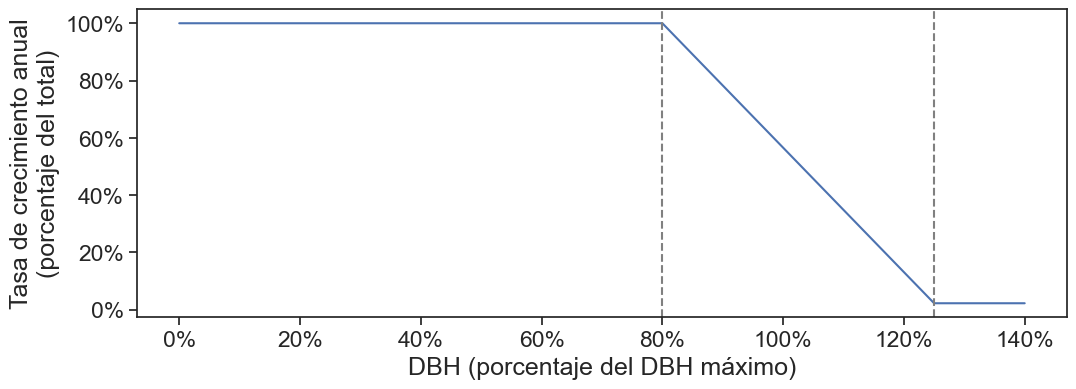

In [11]:
dbh = [0, 0.8, 1.25, 1.4]
rate = [1, 1, 0.022, 0.022]

sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dbh, rate)
ax.set_xlabel("DBH (porcentaje del DBH máximo)")
ax.set_ylabel("Tasa de crecimiento anual\n(porcentaje del total)")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.axvline(0.8, c="gray", ls="--")
ax.axvline(1.25, c="gray", ls="--")
fig.savefig(figure_path / "growth_rate_vs_dbh.jpg", dpi=300, bbox_inches="tight")

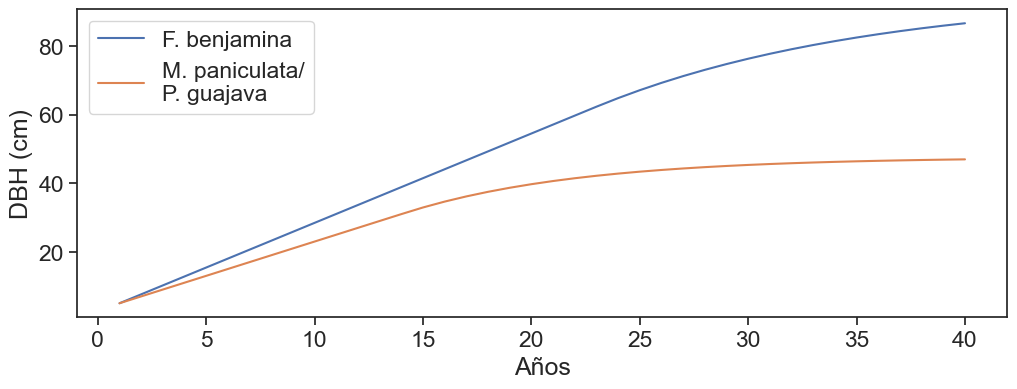

In [48]:
all_diameters = []
for i in range(1, 4):
    d = [
        x["diameter"]
        for x in data["data"]["trees"][str(i)]["benefits"]["annual"]["category"]
    ]
    all_diameters.append(d)

sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, 41), all_diameters[0], label="F. benjamina")
ax.plot(range(1, 41), all_diameters[1], label="M. paniculata/\nP. guajava")
ax.set_xlabel("Años")
ax.set_ylabel("DBH (cm)")
ax.legend()
fig.savefig(figure_path / "dbh_over_time.jpg", dpi=300, bbox_inches="tight")

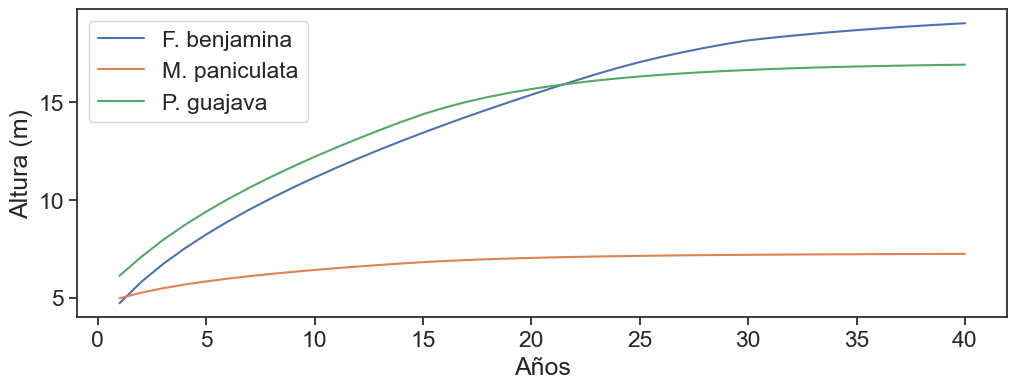

In [49]:
all_heights = []
for i in range(1, 4):
    d = [
        x["height"]
        for x in data["data"]["trees"][str(i)]["benefits"]["annual"]["category"]
    ]
    all_heights.append(d)

sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, 41), all_heights[0], label="F. benjamina")
ax.plot(range(1, 41), all_heights[1], label="M. paniculata")
ax.plot(range(1, 41), all_heights[2], label="P. guajava")
ax.set_xlabel("Años")
ax.set_ylabel("Altura (m)")
ax.legend()
fig.savefig(figure_path / "height_over_time.jpg", dpi=300, bbox_inches="tight")

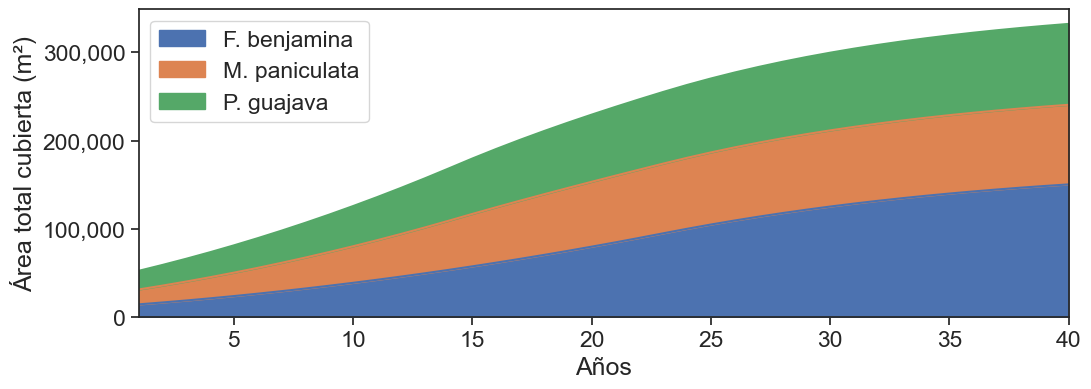

In [128]:
all_crown_areas = []
for i in range(1, 4):
    d = [
        x["crown-area"]
        for x in data["data"]["trees"][str(i)]["benefits"]["annual"]["category"]
    ]
    all_crown_areas.append(d)

all_crown_areas = pd.DataFrame(
    zip(*all_crown_areas),
    columns=["F. benjamina", "M. paniculata", "P. guajava"],
    index=range(1, 41),
).multiply(2149)

sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 4))
all_crown_areas.plot.area(ax=ax)
ax.set_xlim(1, 40)
ax.set_xlabel("Años")
ax.set_ylabel("Área total cubierta (m²)")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
fig.savefig(figure_path / "crown_area_over_time.jpg", dpi=300, bbox_inches="tight")

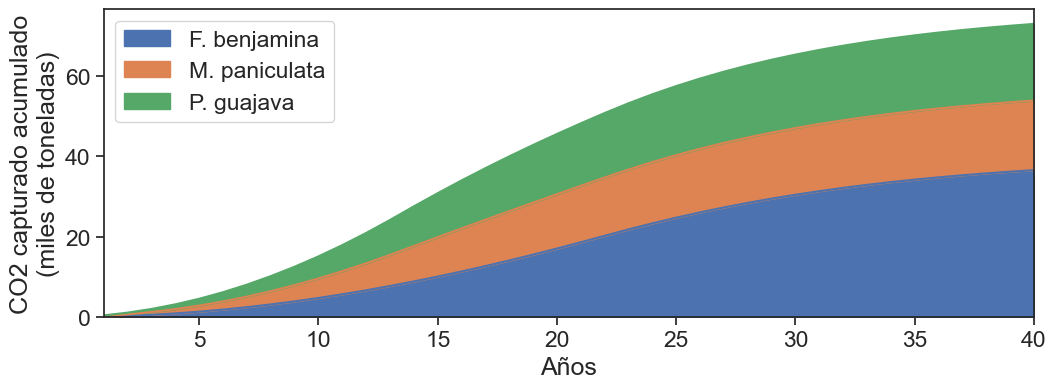

In [146]:
all_sequestrations = []
for i in range(1, 4):
    s = []
    for j in range(40):
        s.append(
            data["data"]["trees"][str(i)]["benefits"]["cumulative"]["category"][j][
                "carbon"
            ]["carbon-dioxide"]["sequestration"],
        )
    all_sequestrations.append(s)

all_sequestrations = pd.DataFrame(
    zip(*all_sequestrations),
    columns=["F. benjamina", "M. paniculata", "P. guajava"],
    index=range(1, 41),
).divide(1e6)

sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 4))
all_sequestrations.plot.area(ax=ax)
ax.set_xlim(1, 40)
ax.set_xlabel("Años")
ax.set_ylabel("CO2 capturado acumulado\n(miles de toneladas)")
fig.savefig(
    figure_path / "carbon_sequestration_over_time.jpg",
    dpi=300,
    bbox_inches="tight",
)

In [140]:
all_sequestrations.iloc[-1].sum()

np.float64(72.89341420319307)

In [ ]:
all_sequestrations.iloc[-1].sum() * 1e6 / 0.2498 * 0.16

np.float64(72893414.20319307)